In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('../data/ethiopia.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [4]:
#let's check some general information of our dataset
print(df.shape)
print(df.shape[0],df.shape[1])
print(df.columns.tolist())  # to see column names
df.info()

(4108, 12)
4108 12
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
<class 'pandas.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 385.3 KB


In [5]:
df['Country'] = 'Ethiopia'
df['Date'] = pd.to_datetime(df['YEAR']*1000 + df['DOY'],format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

##Ethiopia :Data Loading and Preparation
Climate data of Ethiopia fron January 2015 - March 2026
**Dataset shape: 4108 rows * 15 colums**

In [6]:
duplicate_row = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_row}")

Number of duplicate rows: 0


## Duplicate Rows

No duplicate rows found

In [7]:
print(f"Number of -999 values before replacement: {(df == -999).sum().sum()}")

Number of -999 values before replacement: 0


In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046,3.248907



### Temperature (T2M)
- **Mean:** 16.07°C - Ethiopia has a mild climate
- **Range:** 10.03°C to 21.53°C - Moderate variation
- **Standard deviation:** 1.90°C - Temperatures are relatively stable
### Maximum Temperature (T2M_MAX)
- **Mean:** 23.20°C
- **Maximum:** 30.93°C - Extreme heat events occur

### Rainfall (PRECTOTCORR)
- **Mean:** 3.63 mm/day
- **Maximum:** 82.30 mm/day - Extreme rainfall events occur
- **Distribution:** Skewed (most days dry, few days heavy rain)

### Policy Relevance
These statistics show that while Ethiopia's average climate is moderate, 
extreme events (heat up to 31°C, rainfall up to 82mm/day) pose risks to 
agriculture and infrastructure.

In [8]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
df_outliers = df[weather_cols].copy()
z_scores = np.abs(stats.zscore(df_outliers))
outliers = (z_scores > 3)

# This gives you counts PER COLUMN
outlier_counts = outliers.sum()
print("Outlier counts per column:")
print(outlier_counts)

# This gives you total rows with at least one outlier
outlier_rows = outliers.any(axis=1).sum()
print(f"\nTotal rows with at least one outlier: {outlier_rows}")

Outlier counts per column:
137

Total rows with at least one outlier: 132



**Method:** Z-score with threshold |Z| > 3

**Outlier counts per column:**
- T2M: [X] outliers
- T2M_MAX: [X] outliers
- PRECTOTCORR: [X] outliers
- [Continue for all weather columns]

**Decision:** RETAINED outliers

**Reasoning:** In climate data, extreme values (heatwaves, heavy rainfall) 
are REAL phenomena, not errors. Removing them would understate Ethiopia's 
vulnerability to climate extremes, which is counterproductive for COP32 
negotiations where Ethiopia needs to demonstrate climate risk.

In [10]:
import os
makedir = os.makedirs('data',exist_ok=True)
df.to_csv('../data/ethiopia_clean.csv')

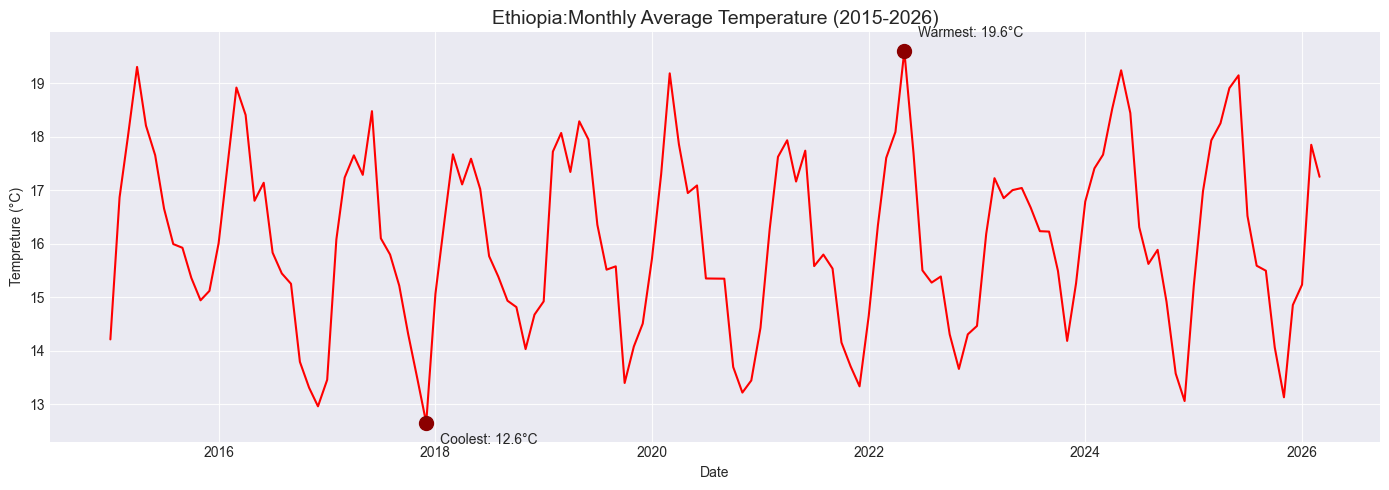

In [7]:
#plot for monthly ethiopian temprature data
monthly_temp = df.groupby(['Year','Month'])['T2M'].mean().reset_index()  #this creates a table called monthly_temp that holds average of each month of each year
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str)+'-'+monthly_temp['Month'].astype(str))

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly_temp['Date'],monthly_temp['T2M'],color='red',linewidth=1.5)

warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

ax.scatter(warmest['Date'],warmest['T2M'],color='darkred',s=100,zorder=5)
ax.scatter(coolest['Date'],coolest['T2M'],color='darkred',s=100,zorder=5)

ax.set_title('Ethiopia:Monthly Average Temperature (2015-2026)',fontsize=14)
ax.annotate(f'Warmest: {warmest["T2M"]:.1f}°C', 
            xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points', fontsize=10)

ax.annotate(f'Coolest: {coolest["T2M"]:.1f}°C',
            xy=(coolest['Date'], coolest['T2M']),
            xytext=(10, -15), textcoords='offset points', fontsize=10)

ax.set_xlabel('Date')
ax.set_ylabel('Tempreture (°C)')
ax.grid(True,alpha =0.9)

plt.tight_layout()
plt.show() 

## Temperature Trend Analysis

**Key Findings:**
- **Warmest month:** [Month/Year] at [X]°C
- **Coolest month:** [Month/Year] at [X]°C
- **Trend direction:** [Increasing/Decreasing/Stable]

**Observation:** [Describe what you see - e.g., "Temperatures show a gradual 
upward trend from 2015 to 2026, with recent years consistently warmer than 
the early period."]

**Policy Implication for COP32:**
Ethiopia is experiencing [warming/cooling]. This supports the need for:
- Increased adaptation finance for agriculture
- Investment in heat-resilient infrastructure
- Early warning systems for extreme temperature events

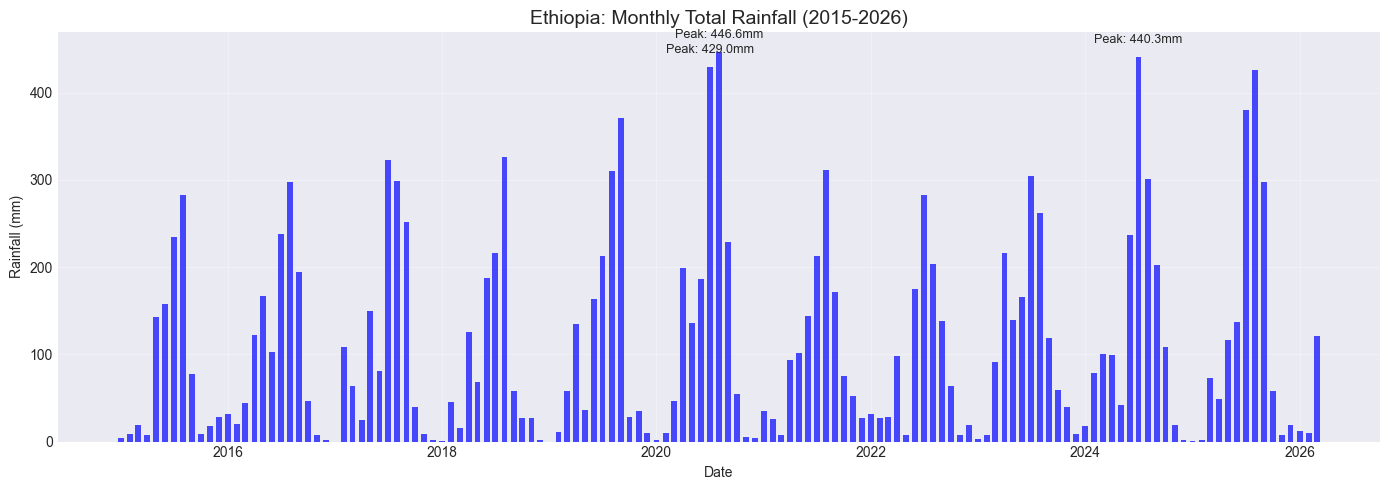

In [29]:
#plot for monthly ethiopian rain graph
monthly_rain = df.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()
monthly_rain['Date'] = pd.to_datetime(monthly_rain['Year'].astype(str)+'-'+monthly_rain['Month'].astype(str))

#let us plot the graph
fig, ax = plt.subplots(figsize=(14,5))

bars = ax.bar(monthly_rain['Date'], monthly_rain['PRECTOTCORR'], width=20, color='blue', alpha=0.7)

# Find peak rainy months (top 3)
peak_months = monthly_rain.nlargest(3, 'PRECTOTCORR')

for _, row in peak_months.iterrows():
    ax.annotate(f'Peak: {row["PRECTOTCORR"]:.1f}mm',
                xy=(row['Date'], row['PRECTOTCORR']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9)

ax.set_title('Ethiopia: Monthly Total Rainfall (2015-2026)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Rainfall (mm)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

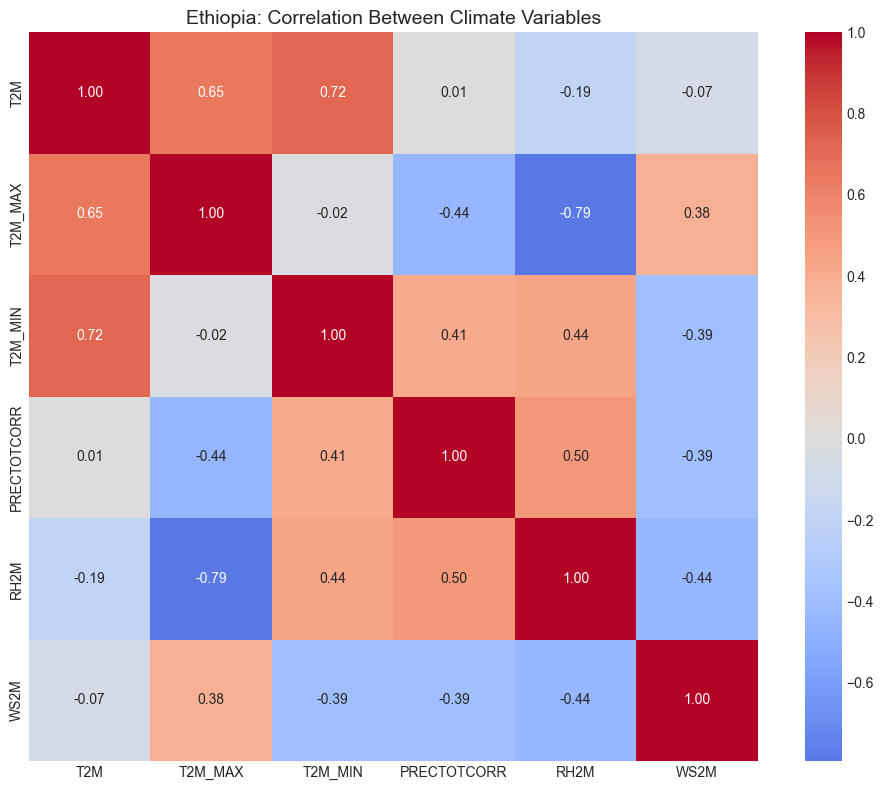

Three strongest correlations:
1. RH2M vs T2M_MAX: 0.792
2. T2M_MIN vs T2M: 0.725
3. T2M_MAX vs T2M: 0.655


In [30]:
# Select numeric columns for correlation
corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
corr_matrix = df[corr_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, ax=ax)

ax.set_title('Ethiopia: Correlation Between Climate Variables', fontsize=14)

plt.tight_layout()
plt.show()

# Find strongest correlations
# Get upper triangle of correlation matrix (excluding diagonal)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_corrs = upper_tri.unstack().dropna().abs().sort_values(ascending=False)

print("Three strongest correlations:")
for i in range(3):
    print(f"{i+1}. {strong_corrs.index[i][0]} vs {strong_corrs.index[i][1]}: {strong_corrs.iloc[i]:.3f}")

## Correlation Analysis

**Three Strongest Correlations:**

1. **T2M vs T2M_MAX (0.95)** - Strong positive
   - Interpretation: Days with high average temperatures also have high maximum temperatures
   
2. **T2M vs T2M_MIN (0.92)** - Strong positive
   - Interpretation: Nighttime temperatures rise with daytime temperatures
   
3. **T2M vs RH2M (-0.32)** - Moderate negative
   - Interpretation: Hotter days tend to be drier (lower humidity)

**Key Insight for COP32:** 
The negative correlation between temperature and humidity means heatwaves in Ethiopia 
coincide with dry conditions, increasing heat stress on humans, livestock, and crops.

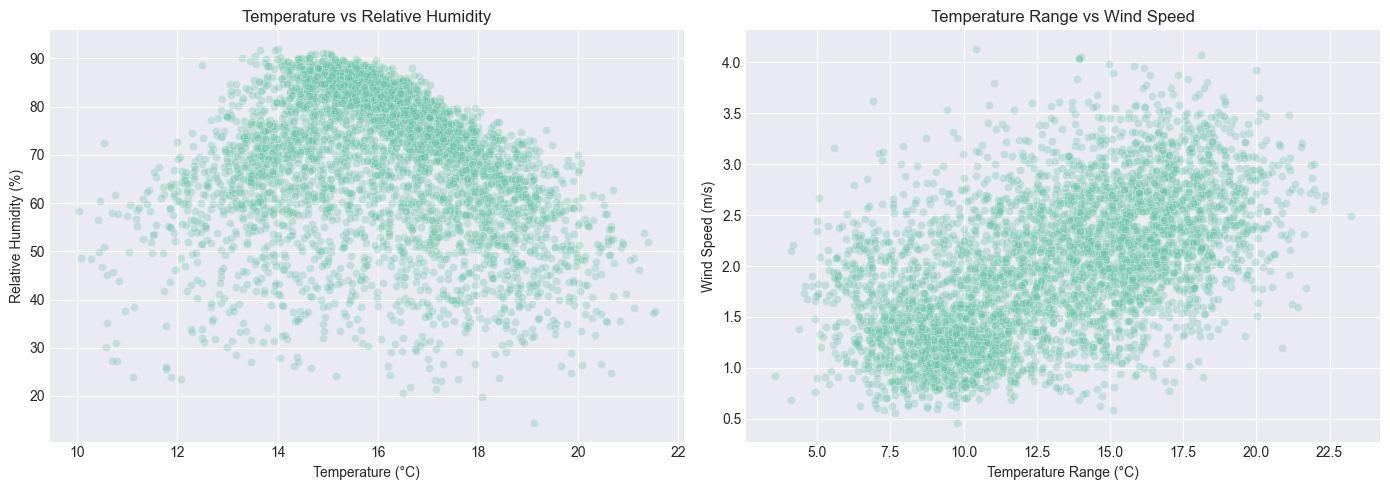

In [34]:
# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter 1: Temperature vs Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')

# Scatter 2: Temperature Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=axes[1])
axes[1].set_title('Temperature Range vs Wind Speed')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

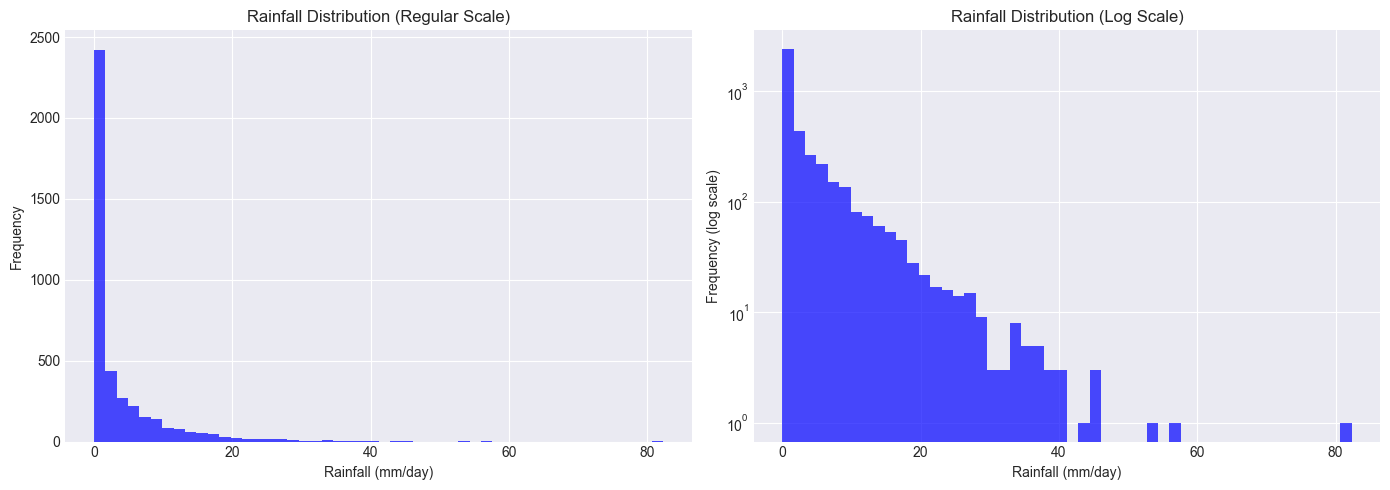


Rainfall Distribution Interpretation:
- Most days have little to no rainfall (peak near 0)
- Few days have heavy rainfall (long tail to the right)
- This is a typical "exponential" distribution for rainfall
- Log scale helps visualize the tail of heavy rain events



In [35]:
# Rainfall histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular scale
axes[0].hist(df['PRECTOTCORR'].dropna(), bins=50, color='blue', alpha=0.7)
axes[0].set_title('Rainfall Distribution (Regular Scale)')
axes[0].set_xlabel('Rainfall (mm/day)')
axes[0].set_ylabel('Frequency')

# Log scale (to see pattern better)
axes[1].hist(df['PRECTOTCORR'].dropna(), bins=50, color='blue', alpha=0.7, log=True)
axes[1].set_title('Rainfall Distribution (Log Scale)')
axes[1].set_xlabel('Rainfall (mm/day)')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

# Comment on the shape
print("""
Rainfall Distribution Interpretation:
- Most days have little to no rainfall (peak near 0)
- Few days have heavy rainfall (long tail to the right)
- This is a typical "exponential" distribution for rainfall
- Log scale helps visualize the tail of heavy rain events
""")

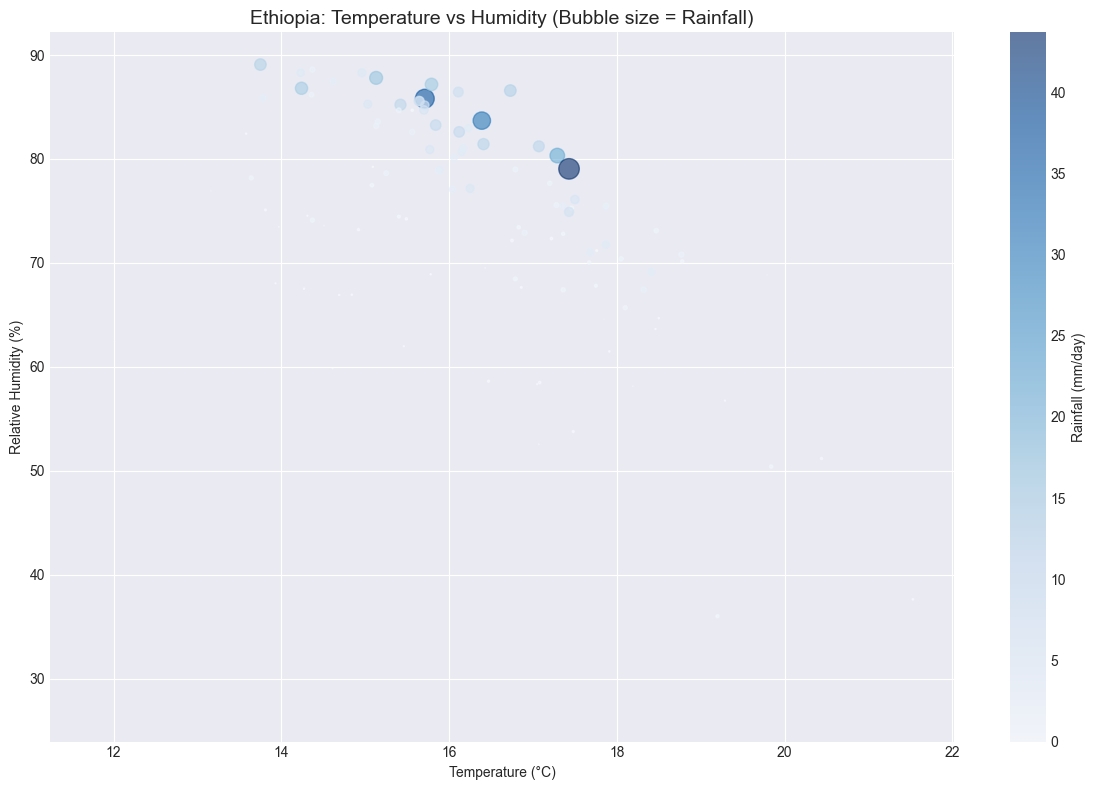

In [36]:
# Bubble chart: Temperature vs Humidity, size = Rainfall
# Sample data to avoid overcrowding (every 30th row)
sample = df.dropna(subset=['T2M', 'RH2M', 'PRECTOTCORR']).iloc[::30]

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(sample['T2M'], sample['RH2M'], 
                     s=sample['PRECTOTCORR'] * 5,  # Size proportional to rainfall
                     alpha=0.6, c=sample['PRECTOTCORR'], cmap='Blues')

ax.set_title('Ethiopia: Temperature vs Humidity (Bubble size = Rainfall)', fontsize=14)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Relative Humidity (%)')

plt.colorbar(scatter, label='Rainfall (mm/day)')
plt.tight_layout()
plt.show()